<a href="https://colab.research.google.com/github/arshdeepverma/subscription-conversion-prediction/blob/main/Subscription_Conversion_Prediction_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Subscription Conversion Prediction — End-to-End ML Project

## Business Problem
A subscription-based app has many free users, but only a portion of them convert to paid subscriptions. The business wants to **predict which free users are likely to become paid customers** using their engagement behavior.

This can help the business:
- Identify high-potential free users
- Prioritize conversion campaigns
- Personalize offers and messaging
- Improve marketing efficiency
- Understand which engagement signals are associated with conversion

## Machine Learning Problem
This is a **supervised binary classification** problem.

### Target Variable
`Converted`

- `1` → User became a paid subscriber
- `0` → User did not become a paid subscriber

### Input Features
- Age
- Days since signup
- Sessions
- Visits
- Features used
- Average session duration
- Trial days used
- Support interactions

## Models Used
We will train and compare three classification algorithms:

1. **Logistic Regression** — interpretable linear baseline
2. **Decision Tree Classifier** — captures non-linear decision rules
3. **Random Forest Classifier** — ensemble of multiple decision trees

## Evaluation Metrics
Models will be compared using:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

## Final Architecture

```text
Raw User Data
      ↓
Data Cleaning
      ↓
EDA
      ↓
Feature Engineering
      ↓
Train / Test Split
      ↓
 ┌────────────────────────────┐
 │ Logistic Regression        │
 │ Decision Tree              │
 │ Random Forest              │
 └────────────────────────────┘
      ↓
Model Evaluation
      ↓
Accuracy | Precision | Recall
F1 | ROC-AUC | Confusion Matrix
      ↓
Select / Tune Model
      ↓
Predict Conversion Probability
```


## 1. Data Source & Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report


## 2. Data Ingestion
Upload the subscription conversion CSV file in Google Colab.

In [3]:
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

print("Dataset shape:", df.shape)
display(df.head())


Saving subscription_conversion_100_users_dirty.csv to subscription_conversion_100_users_dirty (1).csv
Dataset shape: (113, 10)


,User_ID,Age,Days_Since_Signup,Sessions,Visits,Features_Used,Avg_Session_Minutes,Trial_Days_Used,Support_Interactions,Converted
0,U001,46.0,107,8.0,9,4,8.7,20,1.0,0
1,U002,32.0,137,10.0,13,4,14.2,26,3.0,1
2,U003,25.0,7,7.0,18,4,12.4,4,3.0,0
3,U004,38.0,11,15.0,9,2,13.5,0,1.0,0
4,U005,36.0,148,11.0,16,8,12.9,16,1.0,1


## 3. Data Cleaning

In [4]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

# Fill missing numerical values with the median
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print("Shape after cleaning:", df.shape)
print("Total missing values:", df.isnull().sum().sum())


Shape after cleaning: (108, 10)
Total missing values: 0


## 4. EDA — Exploratory Data Analysis

In [5]:
# Basic dataset overview
print("Data types:")
display(df.dtypes.to_frame("Data Type"))

print("\nTarget distribution:")
display(df["Converted"].value_counts().rename({0: "Not Converted", 1: "Converted"}))

print("\nSummary statistics:")
display(df.describe())


Data types:


,Data Type
User_ID,object
Age,float64
Days_Since_Signup,int64
Sessions,float64
Visits,int64
Features_Used,int64
Avg_Session_Minutes,float64
Trial_Days_Used,int64
Support_Interactions,float64
Converted,int64



Target distribution:


,count
Converted,
Converted,62
Not Converted,46



Summary statistics:


,Age,Days_Since_Signup,Sessions,Visits,Features_Used,Avg_Session_Minutes,Trial_Days_Used,Support_Interactions,Converted
count,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000
mean,36.287037,100.870370,10.981481,15.083333,4.990741,14.351852,15.296296,1.500000,0.574074
std,10.635025,47.607251,3.013929,3.811260,2.185318,5.745136,8.528412,1.114895,0.496788
min,18.000000,7.000000,4.000000,6.000000,1.000000,2.000000,0.000000,0.000000,0.000000
25%,26.000000,63.750000,9.000000,12.000000,3.000000,10.500000,8.000000,1.000000,0.000000
50%,38.000000,108.000000,11.000000,15.000000,5.000000,14.250000,16.000000,1.000000,1.000000
75%,44.000000,137.000000,13.000000,17.250000,6.000000,18.200000,22.000000,2.000000,1.000000
max,55.000000,178.000000,17.000000,26.000000,11.000000,31.800000,30.000000,5.000000,1.000000


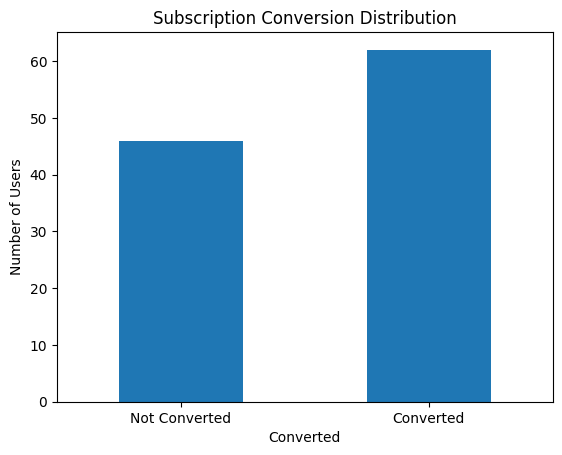

In [6]:
# Target distribution
df["Converted"].value_counts().sort_index().plot(kind="bar")
plt.title("Subscription Conversion Distribution")
plt.xlabel("Converted")
plt.ylabel("Number of Users")
plt.xticks([0, 1], ["Not Converted", "Converted"], rotation=0)
plt.show()


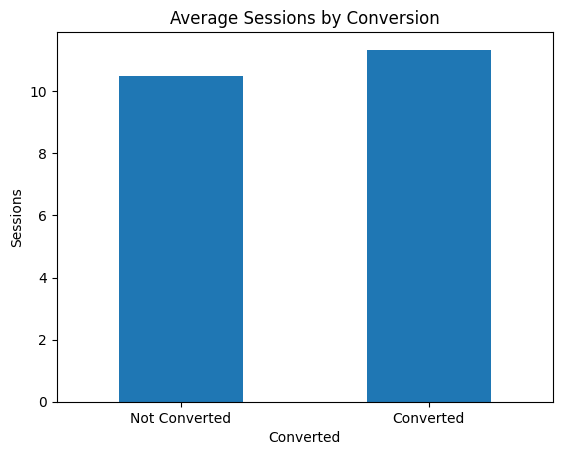

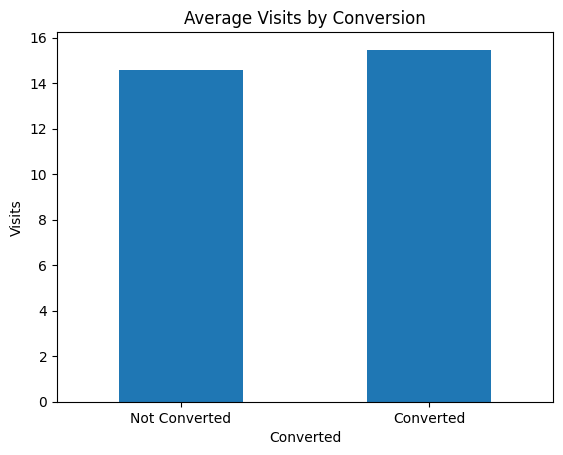

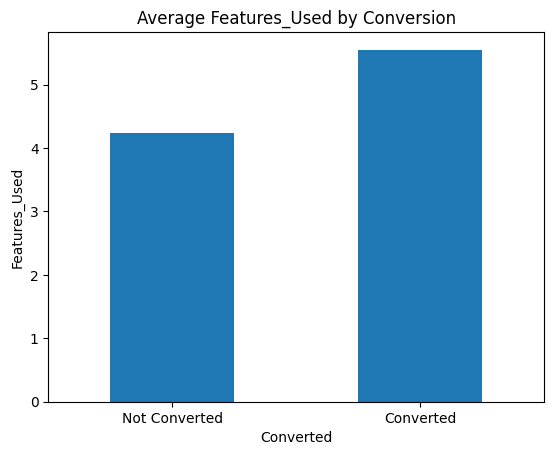

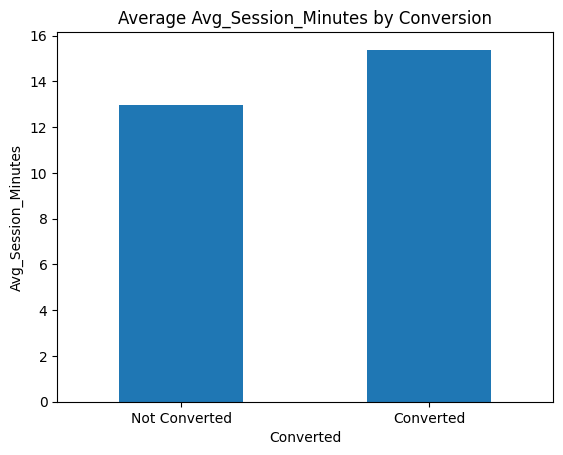

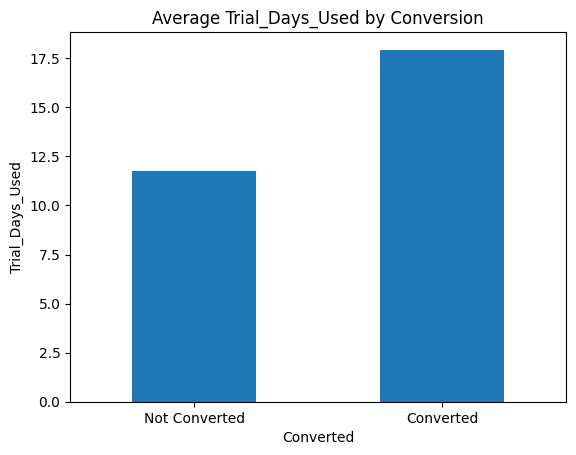

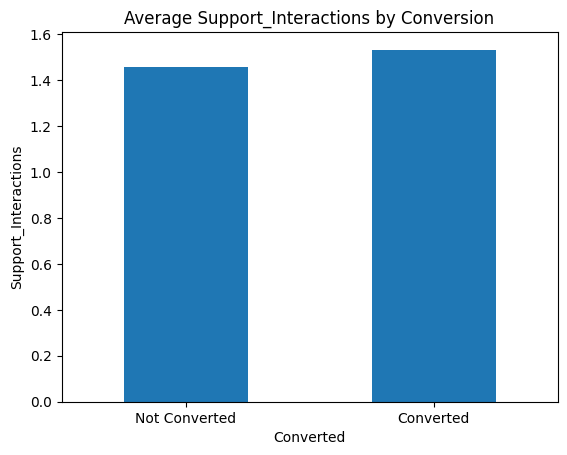

In [7]:
# Relationship between engagement variables and conversion
eda_cols = [
    "Sessions", "Visits", "Features_Used",
    "Avg_Session_Minutes", "Trial_Days_Used",
    "Support_Interactions"
]

for col in eda_cols:
    df.groupby("Converted")[col].mean().plot(kind="bar")
    plt.title(f"Average {col} by Conversion")
    plt.xlabel("Converted")
    plt.ylabel(col)
    plt.xticks([0, 1], ["Not Converted", "Converted"], rotation=0)
    plt.show()


## 5. Feature Engineering

In [8]:
# Create simple engagement-rate features
df["Sessions_Per_Day"] = df["Sessions"] / df["Days_Since_Signup"].clip(lower=1)
df["Visits_Per_Day"] = df["Visits"] / df["Days_Since_Signup"].clip(lower=1)

display(df.head())


,User_ID,Age,Days_Since_Signup,Sessions,Visits,Features_Used,Avg_Session_Minutes,Trial_Days_Used,Support_Interactions,Converted,Sessions_Per_Day,Visits_Per_Day
0,U001,46.0,107,8.0,9,4,8.7,20,1.0,0,0.074766,0.084112
1,U002,32.0,137,10.0,13,4,14.2,26,3.0,1,0.072993,0.094891
2,U003,25.0,7,7.0,18,4,12.4,4,3.0,0,1.000000,2.571429
3,U004,38.0,11,15.0,9,2,13.5,0,1.0,0,1.363636,0.818182
4,U005,36.0,148,11.0,16,8,12.9,16,1.0,1,0.074324,0.108108


## 6. Feature Selection

In [9]:
# User_ID is an identifier, not a predictive feature
target = "Converted"

feature_cols = [
    "Age",
    "Days_Since_Signup",
    "Sessions",
    "Visits",
    "Features_Used",
    "Avg_Session_Minutes",
    "Trial_Days_Used",
    "Support_Interactions",
    "Sessions_Per_Day",
    "Visits_Per_Day"
]

X = df[feature_cols]
y = df[target]

print("Selected features:")
print(feature_cols)


Selected features:
['Age', 'Days_Since_Signup', 'Sessions', 'Visits', 'Features_Used', 'Avg_Session_Minutes', 'Trial_Days_Used', 'Support_Interactions', 'Sessions_Per_Day', 'Visits_Per_Day']


## 7. Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 86
Testing rows: 22


## 8. Model Training

In [11]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=8, random_state=42
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)

print("All models trained successfully.")


All models trained successfully.


## 9. Model Evaluation

In [12]:
results = []

for name, model in models.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1 Score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
display(results_df)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.863636,0.857143,0.923077,0.888889,0.871795
1,Logistic Regression,0.818182,0.800000,0.923077,0.857143,0.846154
2,Decision Tree,0.818182,0.800000,0.923077,0.857143,0.777778


## 10. Best Model Selection

In [13]:
# Select the best model based on F1 Score (change the metric below if a different
# business priority — e.g. Recall to catch more potential converters — is preferred)
selection_metric = "F1 Score"

best_model_name = results_df.sort_values(selection_metric, ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

print(f"Best model selected (by {selection_metric}): {best_model_name}")
print("\nMetrics for selected model:")
display(results_df[results_df["Model"] == best_model_name])


Best model selected (by F1 Score): Random Forest

Metrics for selected model:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.863636,0.857143,0.923077,0.888889,0.871795


## 11. Feature Importance (Best Model)

In [14]:
# Works regardless of which model was selected:
# - Tree-based models (Decision Tree, Random Forest) expose feature_importances_
# - Logistic Regression (wrapped in a Pipeline) exposes coefficients instead,
#   so we use their absolute value as an importance proxy

def get_estimator(model):
    """Unwrap a Pipeline to get the underlying estimator, if needed."""
    if hasattr(model, "named_steps"):
        return model.named_steps["model"]
    return model

estimator = get_estimator(best_model)

if hasattr(estimator, "feature_importances_"):
    importance_values = estimator.feature_importances_
    importance_label = "Importance"
elif hasattr(estimator, "coef_"):
    importance_values = np.abs(estimator.coef_[0])
    importance_label = "Importance (|coefficient|)"
else:
    raise ValueError("Selected model does not expose feature importances or coefficients.")

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    importance_label: importance_values
}).sort_values(importance_label, ascending=False).reset_index(drop=True)

display(importance_df)


,Feature,Importance
0,Trial_Days_Used,0.204778
1,Avg_Session_Minutes,0.141467
2,Sessions_Per_Day,0.107179
3,Visits_Per_Day,0.097202
4,Features_Used,0.093804
5,Age,0.088609
6,Days_Since_Signup,0.085768
7,Sessions,0.076846
8,Support_Interactions,0.052696
9,Visits,0.051650


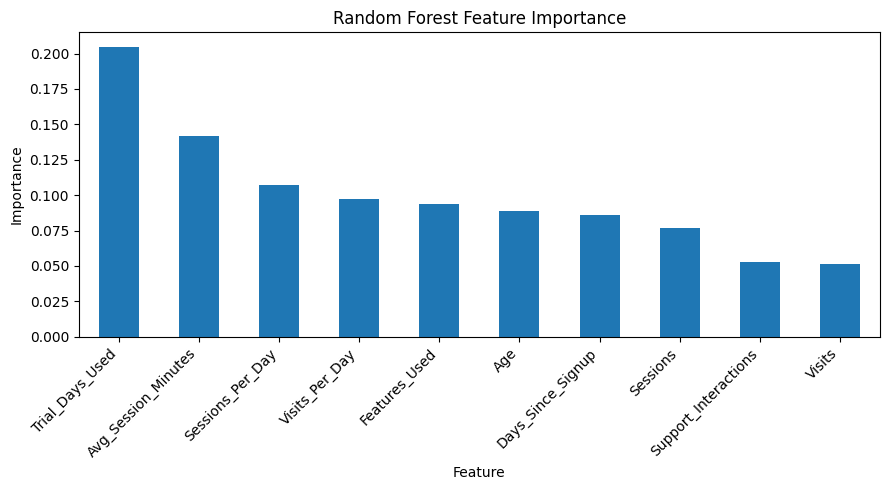

In [15]:
importance_df.plot(
    x="Feature",
    y=importance_label,
    kind="bar",
    legend=False,
    figsize=(9, 5)
)
plt.title(f"{best_model_name} Feature Importance")
plt.xlabel("Feature")
plt.ylabel(importance_label)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 12. Confusion Matrix (Best Model)

In [16]:
best_pred = best_model.predict(X_test)

print("Selected model:", best_model_name)
print("\nClassification Report:")
print(classification_report(y_test, best_pred, zero_division=0))

cm = confusion_matrix(y_test, best_pred)
print("Confusion Matrix (raw counts):")
print(cm)


Selected model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.82         9
           1       0.86      0.92      0.89        13

    accuracy                           0.86        22
   macro avg       0.87      0.85      0.86        22
weighted avg       0.86      0.86      0.86        22

Confusion Matrix (raw counts):
[[ 7  2]
 [ 1 12]]


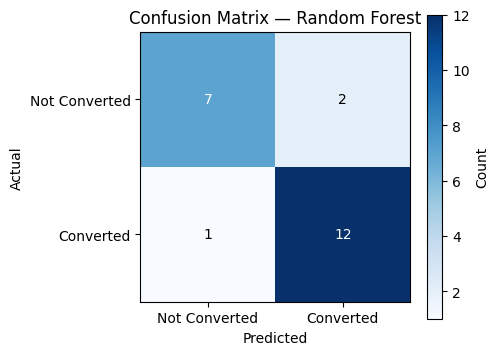

In [17]:
# Visual confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")

labels = ["Not Converted", "Converted"]
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best_model_name}")

# Annotate each cell with its count
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()


## 13. Prediction & Reporting

In [18]:
# Predict conversion probability for the test users
prediction_output = X_test.copy()
prediction_output["Actual_Converted"] = y_test.values
prediction_output["Predicted_Converted"] = best_pred
prediction_output["Conversion_Probability"] = best_model.predict_proba(X_test)[:, 1]

display(prediction_output.head(10))


,Age,Days_Since_Signup,Sessions,Visits,Features_Used,Avg_Session_Minutes,Trial_Days_Used,Support_Interactions,Sessions_Per_Day,Visits_Per_Day,Actual_Converted,Predicted_Converted,Conversion_Probability
31,26.0,140,11.0,15,6,20.8,22,2.0,0.078571,0.107143,1,1,0.963623
8,41.0,21,14.0,10,8,19.9,9,0.0,0.666667,0.476190,1,0,0.478542
11,20.0,130,13.0,20,7,11.3,17,4.0,0.100000,0.153846,1,1,0.899659
20,29.0,35,12.0,16,3,14.7,24,2.0,0.342857,0.457143,1,1,0.529255
96,52.0,99,14.0,21,5,14.3,12,1.0,0.141414,0.212121,1,1,0.808037
93,40.0,103,11.0,10,2,16.3,8,1.0,0.106796,0.097087,0,0,0.419396
50,21.0,68,5.0,23,6,4.2,21,3.0,0.073529,0.338235,0,0,0.479545
85,22.0,151,14.0,17,6,17.1,29,1.0,0.092715,0.112583,0,1,0.907263
90,29.0,104,9.0,13,6,16.2,30,0.0,0.086538,0.125000,1,1,0.873126
38,19.0,81,9.0,17,6,11.0,27,1.0,0.111111,0.209877,1,1,0.784004


In [19]:
# Simple business segmentation
prediction_output["Segment"] = pd.cut(
    prediction_output["Conversion_Probability"],
    bins=[-0.01, 0.33, 0.66, 1.0],
    labels=["Low Potential", "Medium Potential", "High Potential"]
)

display(
    prediction_output[
        ["Actual_Converted", "Predicted_Converted", "Conversion_Probability", "Segment"]
    ].head(10)
)


,Actual_Converted,Predicted_Converted,Conversion_Probability,Segment
31,1,1,0.963623,High Potential
8,1,0,0.478542,Medium Potential
11,1,1,0.899659,High Potential
20,1,1,0.529255,Medium Potential
96,1,1,0.808037,High Potential
93,0,0,0.419396,Medium Potential
50,0,0,0.479545,Medium Potential
85,0,1,0.907263,High Potential
90,1,1,0.873126,High Potential
38,1,1,0.784004,High Potential


## Final Summary

### Business Objective
Predict which free users are likely to convert to paid subscribers.

### Final Pipeline
**Data Source → Data Ingestion → Data Cleaning → EDA → Feature Engineering → Feature Selection → Train-Test Split → Model Training → Model Evaluation → Best Model Selection → Feature Importance → Confusion Matrix → Prediction / Reporting**

### Output
The project produces:
- Cleaned data
- EDA insights
- Engineered features
- Selected input features
- Trained classification models
- Model evaluation metrics for all candidate models
- The selected best-performing model
- Feature importance for the selected model
- A confusion matrix (report + visual heatmap) for the selected model
- Conversion predictions and probabilities
